In [1]:
# Created path for the csv files and checked to see if it is actually there
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/My Drive"

 Citibike_worldcup_project   Classroom	'Colab Notebooks'


In [3]:
!ls "/content/drive/My Drive/Citibike_worldcup_project"

data


In [4]:
!ls "/content/drive/My Drive/Citibike_worldcup_project/data"

202507-citibike-tripdata_1.csv	202507-citibike-tripdata_4.csv
202507-citibike-tripdata_2.csv	202507-citibike-tripdata_5.csv
202507-citibike-tripdata_3.csv	citibike_analysis.ipynb


In [5]:
import pandas as pd
import glob

#Path to my data folder in Google Drive
path = "/content/drive/My Drive/Citibike_worldcup_project/data/*.csv"

file_paths = glob.glob(path)
file_paths

['/content/drive/My Drive/Citibike_worldcup_project/data/202507-citibike-tripdata_5.csv',
 '/content/drive/My Drive/Citibike_worldcup_project/data/202507-citibike-tripdata_4.csv',
 '/content/drive/My Drive/Citibike_worldcup_project/data/202507-citibike-tripdata_1.csv',
 '/content/drive/My Drive/Citibike_worldcup_project/data/202507-citibike-tripdata_3.csv',
 '/content/drive/My Drive/Citibike_worldcup_project/data/202507-citibike-tripdata_2.csv']

In [7]:
# Combine all 5 csv files into one df
df_list = [pd.read_csv(file) for file in file_paths]

df = pd.concat(df_list, ignore_index=True)
df.head()

/tmp/ipykernel_3543/2993001701.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in file_paths]
/tmp/ipykernel_3543/2993001701.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in file_paths]
/tmp/ipykernel_3543/2993001701.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in file_paths]
/tmp/ipykernel_3543/2993001701.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in file_paths]
/tmp/ipykernel_3543/2993001701.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in file_paths]


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,4DD2787D61CF3241,electric_bike,2025-07-18 17:25:37.739,2025-07-18 17:47:53.285,49 St & 25 Ave,6804.01,48 St & Broadway,6629.06,40.764496,-73.904632,40.755763,-73.912715,casual
1,773CBF1A04FD71AB,electric_bike,2025-07-19 15:28:29.468,2025-07-19 16:04:17.964,Central Park S & 6 Ave,6876.04,5 Ave & E 72 St,7100.07,40.765909,-73.976342,40.772828,-73.966853,casual
2,D68E54237896E734,electric_bike,2025-07-17 23:27:57.316,2025-07-17 23:40:52.640,Leonard St & Church St,5359.11,Liberty St & Broadway,5105.01,40.717571,-74.005549,40.709056,-74.010434,casual
3,925D499017AC875C,electric_bike,2025-07-24 13:37:21.526,2025-07-24 13:44:39.234,Central Park S & 6 Ave,6876.04,5 Ave & E 72 St,7100.07,40.765909,-73.976342,40.772828,-73.966853,casual
4,2E66E951D8461F26,electric_bike,2025-07-27 18:58:50.703,2025-07-27 19:21:55.612,Central Park S & 6 Ave,6876.04,5 Ave & E 72 St,7100.07,40.765909,-73.976342,40.772828,-73.966853,casual


<Axes: >

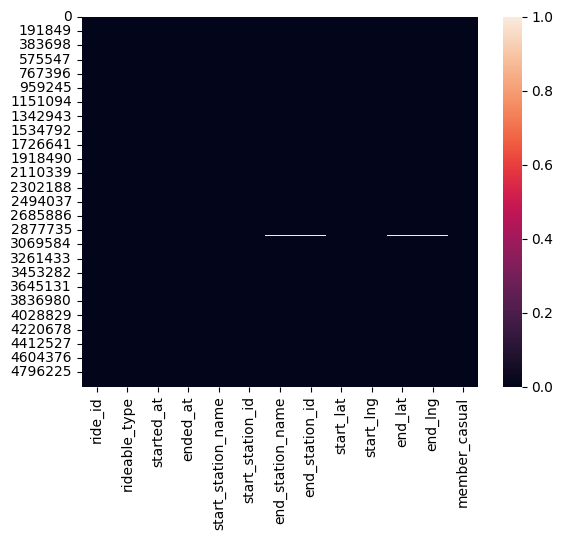

In [8]:
import seaborn as sns
sns.heatmap(df.isnull())

In [9]:
# Dropped rows missing essential fields
# From the heatmap, missing rows are clearly identified
df = df.dropna(subset=["start_station_id", "end_station_id","start_lat", "start_lng", "end_lat", "end_lng"])

In [10]:
# Converted timestamps to datetime and set them as index
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])

In [12]:
# Created trip duration and remove bad trips.
df["trip_duration_min"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60

# Removed negative or unrealistic trips
df = df[(df["trip_duration_min"] > 0) & (df["trip_duration_min"] <= 180)]


In [13]:
# Created time features for analysis
df["date"] = df["started_at"].dt.date
df["hour"] = df["started_at"].dt.hour
df["day_of_week"] = df["started_at"].dt.day_name()
df["month"] = df["started_at"].dt.month
df["year"] = df["started_at"].dt.year
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])

In [14]:
# Remove duplicate rows
df = df.drop_duplicates()

In [15]:
# final checks to make df ready for my analysis
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 4960024 entries, 0 to 4988052
Data columns (total 20 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    object        
 6   end_station_name    object        
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
 13  trip_duration_min   float64       
 14  date                object        
 15  hour                int32         
 16  day_of_week         object        
 17  month               int32         
 18  year                int32         
 19  is_weekend          bool          
dtypes: bool

,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,0
start_station_id,0
end_station_name,0
end_station_id,0
start_lat,0
start_lng,0


###The next step explains the data with reference to trends and demand over time

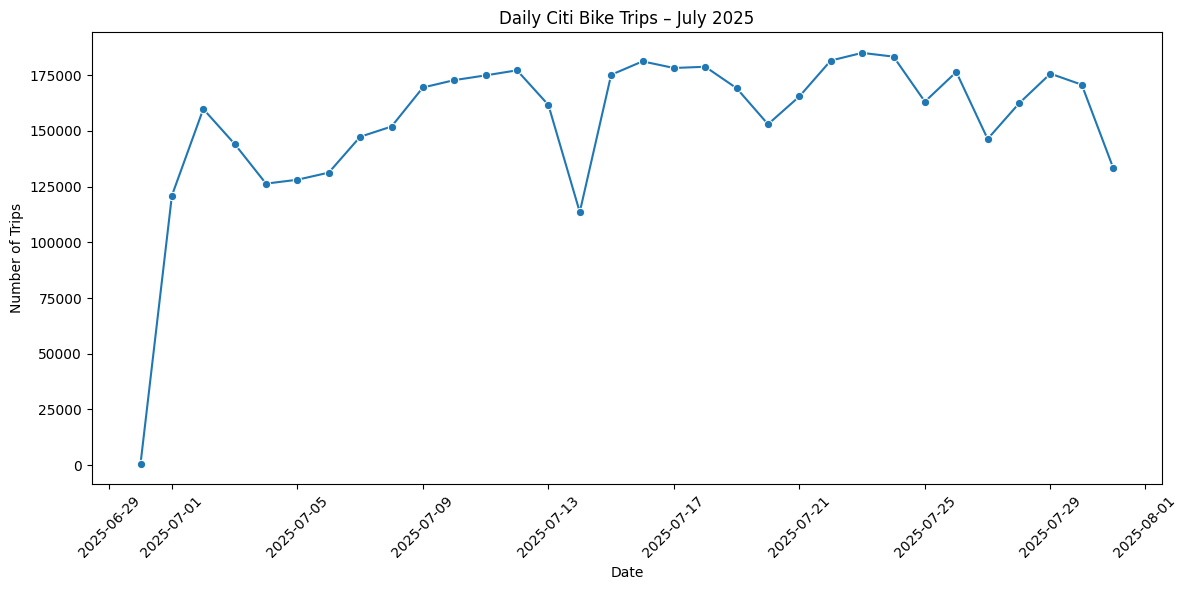

In [16]:
# Daily trip volume
import matplotlib.pyplot as plt
import seaborn as sns

daily_trips = df.groupby("date")["ride_id"].count().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=daily_trips, x="date", y="ride_id", marker="o")
plt.title("Daily Citi Bike Trips – July 2025")
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### What this means:

1.   Which days had the highest demand?
2.   Does weekends spike?
1.   Does mid-month dips or peaks?






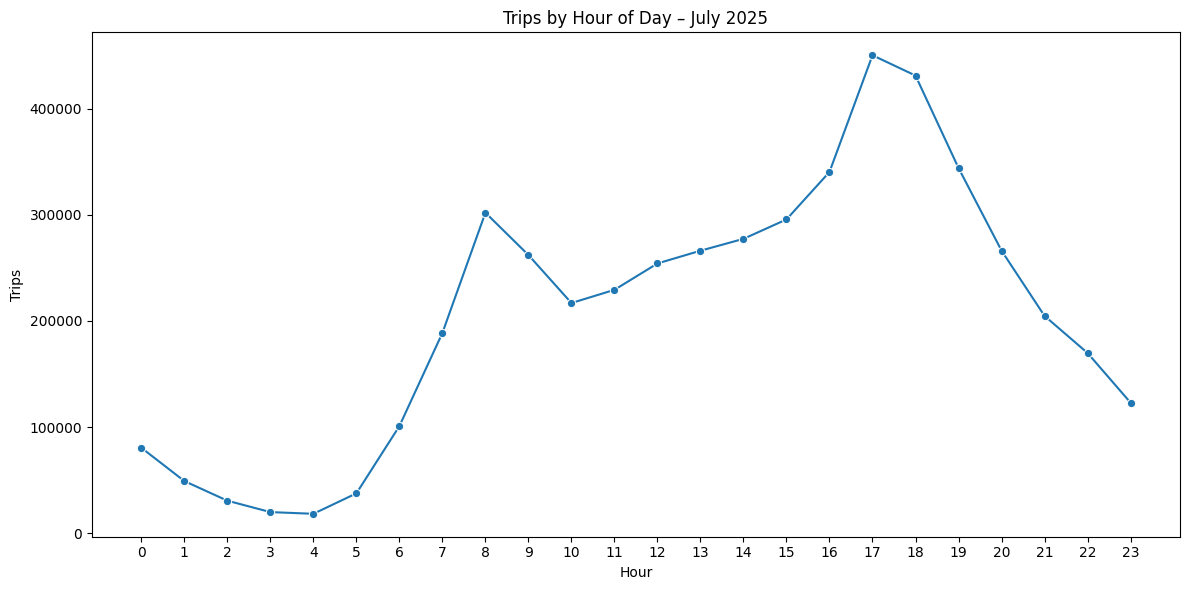

In [17]:
# Trips  by Hour
hourly_trips = df.groupby("hour")["ride_id"].count().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=hourly_trips, x="hour", y="ride_id", marker="o")
plt.title("Trips by Hour of Day – July 2025")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

###**Insight:**  
Morning commute (7–9 AM) and evening commute (4–7 PM) usually dominate.

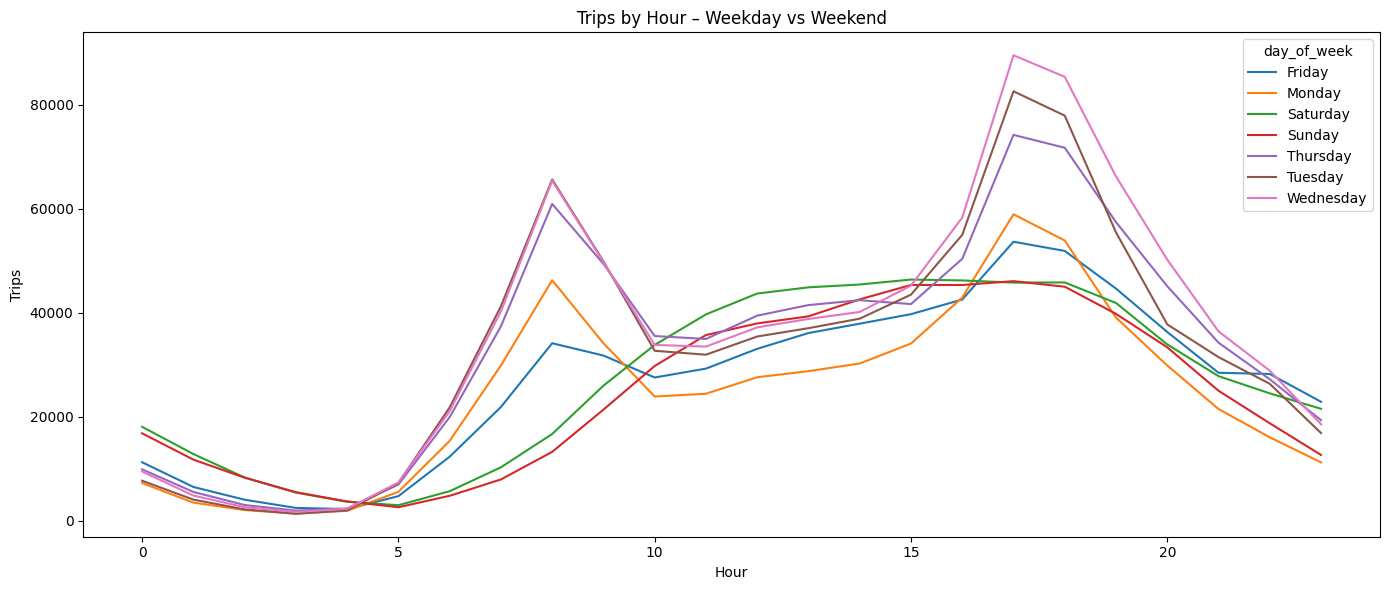

In [18]:
# Weekday vrs Weekend
weekday_hour = df.groupby(["day_of_week", "hour"])["ride_id"].count().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=weekday_hour, x="hour", y="ride_id", hue="day_of_week")
plt.title("Trips by Hour – Weekday vs Weekend")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.tight_layout()
plt.show()

###**Insight:**  
Weekends often show late‑morning and evening spikes (mainly by tourist and leisure).

### This section explains the usage behaviours of member and casual riders

/tmp/ipykernel_3543/2938626626.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=member_counts.index, y=member_counts.values, palette="Set2")


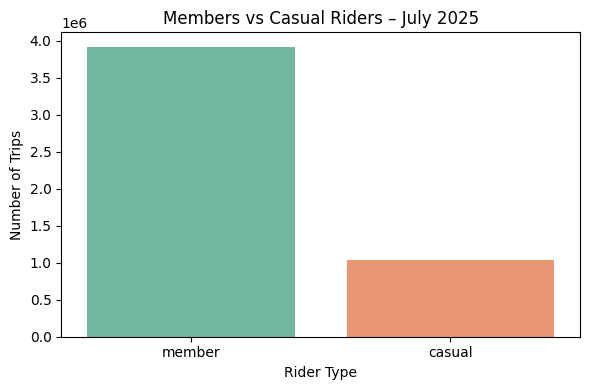

In [19]:
# How many members vrs casual members riders
member_counts = df["member_casual"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=member_counts.index, y=member_counts.values, palette="Set2")
plt.title("Members vs Casual Riders – July 2025")
plt.xlabel("Rider Type")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3543/649645605.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="member_casual", y="trip_duration_min", palette="Set3")


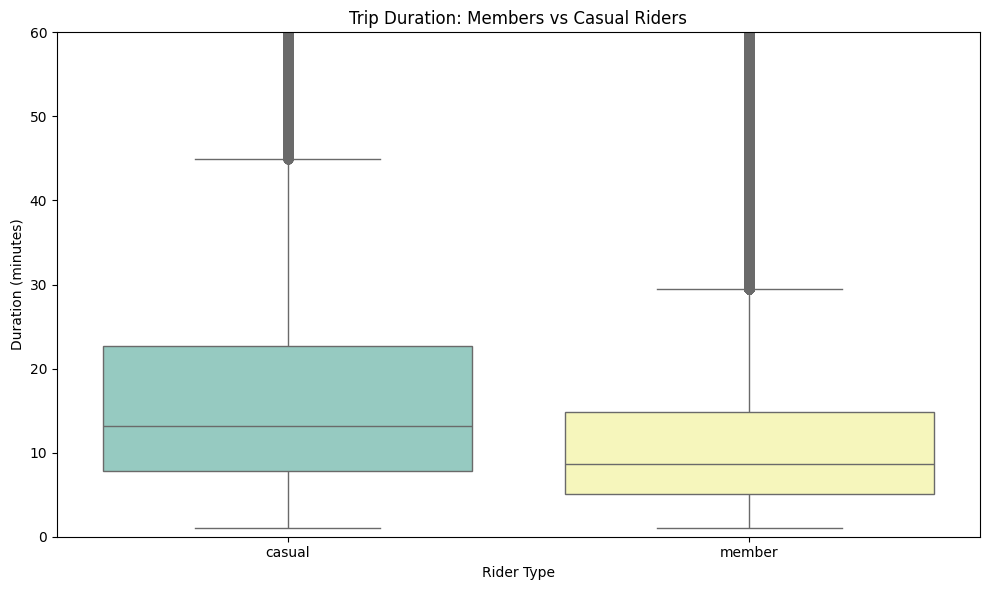

In [20]:
# Calculating trip duration by membership
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="member_casual", y="trip_duration_min", palette="Set3")
plt.title("Trip Duration: Members vs Casual Riders")
plt.xlabel("Rider Type")
plt.ylabel("Duration (minutes)")
plt.ylim(0, 60)
plt.tight_layout()
plt.show()

###**insight:**

1.   Casual riders take longer trips (tourism, leisure)
2.   Members take shorter, consistent trips (commuting)







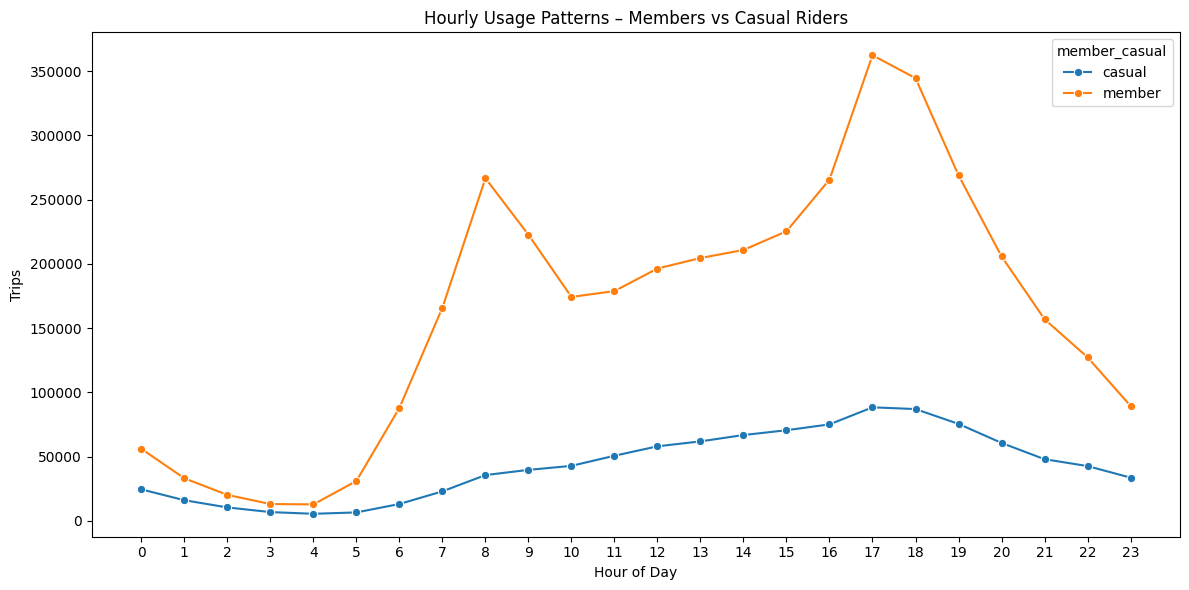

In [21]:
# Calculating hourly usage by membership
hourly = df.groupby(["member_casual", "hour"])["ride_id"].count().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=hourly, x="hour", y="ride_id", hue="member_casual", marker="o")
plt.title("Hourly Usage Patterns – Members vs Casual Riders")
plt.xlabel("Hour of Day")
plt.ylabel("Trips")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

###**insight:**

1.   Members: strong morning (7–9 AM) and evening (4–7 PM) commute peaks
2.   Casual: late morning and afternoon peaks, especially weekends







### This next step is going to elborate which stations have high demands and stations in world cup fan zone areas

/tmp/ipykernel_3543/1880005514.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_starts, x="ride_id", y="start_station_name", palette="viridis")


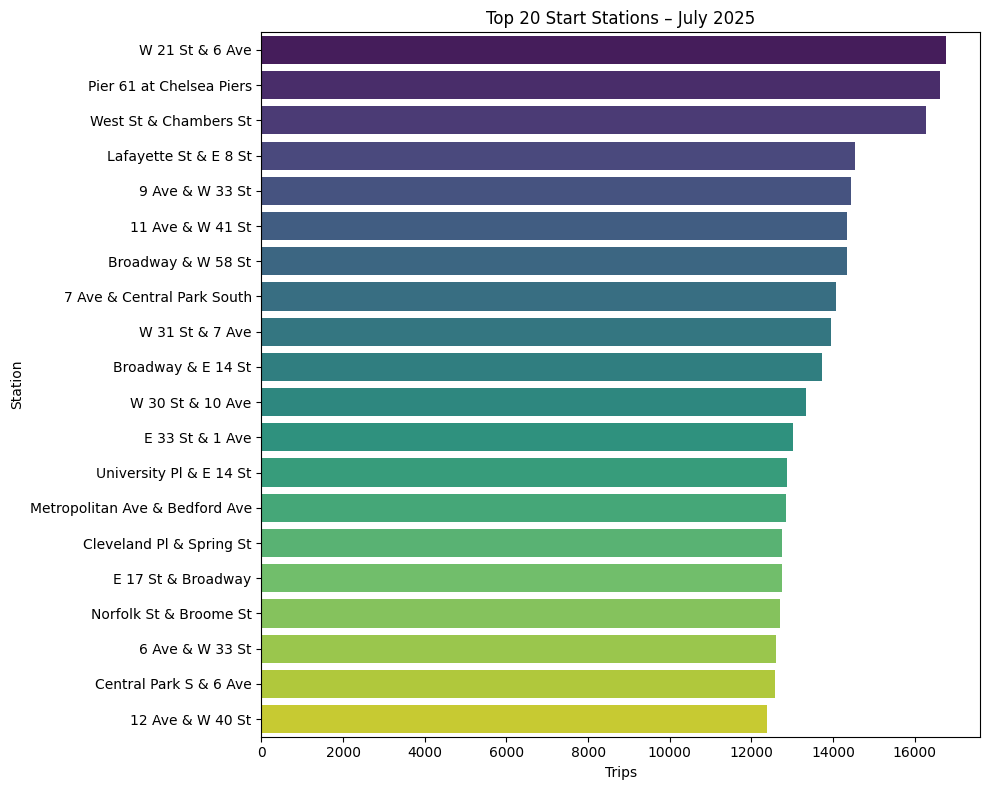

In [22]:
# Top 20 stations
top_starts = (
    df.groupby(["start_station_name", "start_lat", "start_lng"])["ride_id"]
    .count()
    .reset_index()
    .sort_values("ride_id", ascending=False)
    .head(20)
)

plt.figure(figsize=(10,8))
sns.barplot(data=top_starts, x="ride_id", y="start_station_name", palette="viridis")
plt.title("Top 20 Start Stations – July 2025")
plt.xlabel("Trips")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

### Insights:
These are the high -pressure stations critical for the world cup planning

In [23]:
# Stations that normally run out of bikes or docks
departures = df.groupby("start_station_name")["ride_id"].count().reset_index()
departures.columns = ["station", "departures"]

arrivals = df.groupby("end_station_name")["ride_id"].count().reset_index()
arrivals.columns = ["station", "arrivals"]

flow = departures.merge(arrivals, on="station", how="outer").fillna(0)
flow["net_flow"] = flow["departures"] - flow["arrivals"]

top_outflow = flow.sort_values("net_flow", ascending=False).head(15)
top_inflow = flow.sort_values("net_flow").head(15)

/tmp/ipykernel_3543/3918949393.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_outflow, x="net_flow", y="station", palette="Reds")


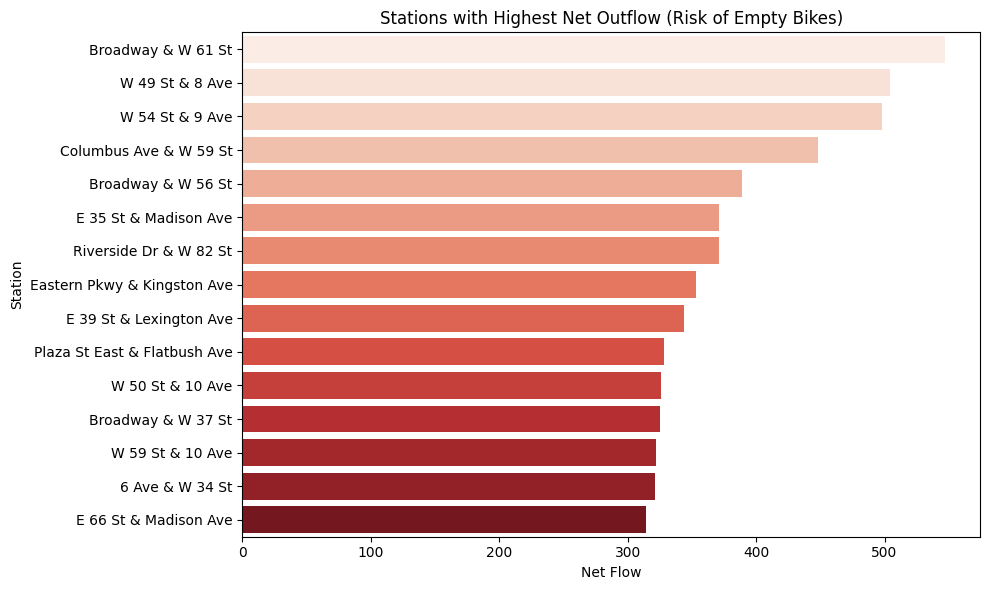

In [24]:
# Stations like to run out of bikes
plt.figure(figsize=(10,6))
sns.barplot(data=top_outflow, x="net_flow", y="station", palette="Reds")
plt.title("Stations with Highest Net Outflow (Risk of Empty Bikes)")
plt.xlabel("Net Flow")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3543/230579570.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_inflow, x="net_flow", y="station", palette="Blues_r")


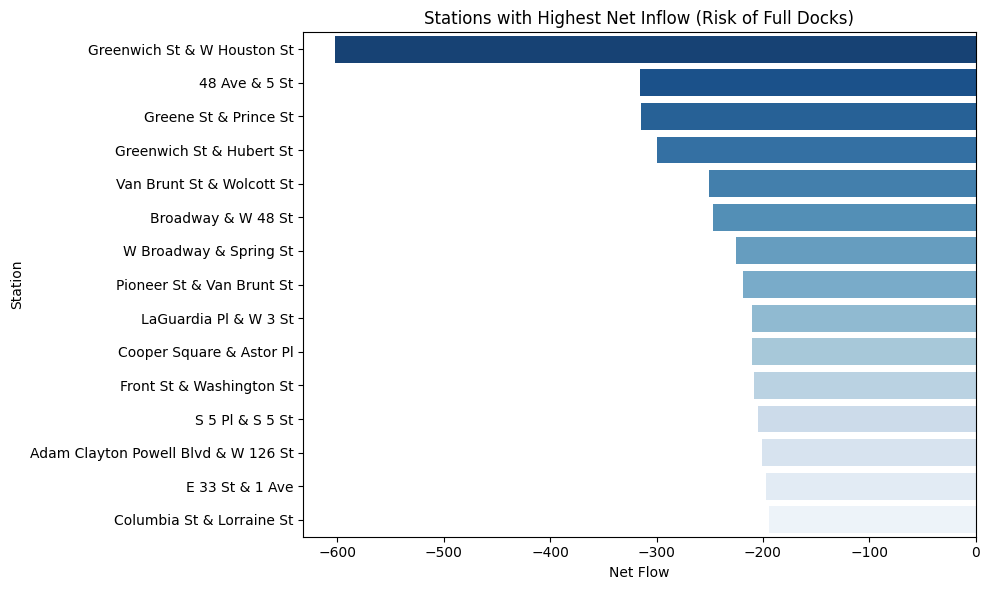

In [25]:
# Stations likely to run out of docks
plt.figure(figsize=(10,6))
sns.barplot(data=top_inflow, x="net_flow", y="station", palette="Blues_r")
plt.title("Stations with Highest Net Inflow (Risk of Full Docks)")
plt.xlabel("Net Flow")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

###**Insight: **
These stations need more docks or more frequent rebalancing.

### focusing on downtown Manhattan as a designated fanzone for the 2026 Fifa World cup in NYC.

In [26]:
# Focusing on Manhattan
manhattan = df[(df["start_lat"] > 40.70) & (df["start_lat"] < 40.88) &
               (df["start_lng"] > -74.02) & (df["start_lng"] < -73.92)]

manhattan_stations = manhattan.groupby(["start_station_id", "start_station_name", "start_lat", "start_lng"])["ride_id"].count().reset_index()
manhattan_stations = manhattan_stations.rename(columns={"ride_id": "trip_count"})

manhattan_top = manhattan_stations.sort_values("trip_count", ascending=False).head(20)
manhattan_top


,start_station_id,start_station_name,start_lat,start_lng,trip_count
395,6140.05,W 21 St & 6 Ave,40.741740,-73.994156,16758
427,6233.04,Pier 61 at Chelsea Piers,40.746872,-74.008210,16624
149,5329.03,West St & Chambers St,40.717548,-74.013221,16285
303,5788.13,Lafayette St & E 8 St,40.730207,-73.991026,14526
500,6492.08,9 Ave & W 33 St,40.752568,-73.996765,14436
571,6726.01,11 Ave & W 41 St,40.760301,-73.998842,14334
633,6948.10,Broadway & W 58 St,40.766953,-73.981693,14328
624,6912.01,7 Ave & Central Park South,40.766741,-73.979069,14077
458,6331.01,W 31 St & 7 Ave,40.749156,-73.991600,13959
328,5905.12,Broadway & E 14 St,40.734546,-73.990741,13720


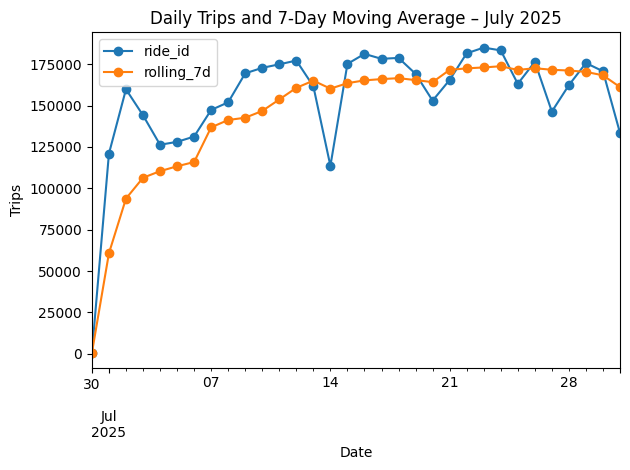

In [27]:
# Daily trips
daily = df.groupby("date")["ride_id"].count().reset_index()
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.set_index("date")

# Simple moving average as a naive forecast
daily["rolling_7d"] = daily["ride_id"].rolling(window=7, min_periods=1).mean()

daily[["ride_id", "rolling_7d"]].plot(marker="o")
plt.title("Daily Trips and 7-Day Moving Average – July 2025")
plt.xlabel("Date")
plt.ylabel("Trips")
plt.tight_layout()
plt.show()


###Using July 2025 as a high‑demand baseline, we can expect similar or higher daily trip volumes during peak World Cup periods, especially around event venues and transit hubs